# Analyse exploratoire du dataset FRED — Projet Statistical Learning M1 MA Dauphine

Ce notebook présente l'analyse exploratoire (EDA) du dataset utilisé pour le projet de *Statistical Learning* du M1 Mathématiques & Applications de l'Université Paris Dauphine. L'objectif du projet est de **prédire la courbe des taux US Treasury** par régression supervisée, en comparant plusieurs méthodes (OLS, Ridge, PCR/PLS). Les données proviennent de la base [FRED](https://fred.stlouisfed.org/) (Federal Reserve Bank of St. Louis) et couvrent la période du 1ᵉʳ janvier 1990 à aujourd'hui, à la fréquence des jours ouvrés.

La démarche de ce notebook commence par un rappel du **contexte financier** nécessaire à la compréhension des données, puis par une **illustration visuelle** de la courbe des taux, avant d'entrer dans la description technique du dataset. La démarche EDA suit ensuite une progression classique : d'abord la structure du dataset et la sémantique des variables (Section 1), puis l'analyse des valeurs manquantes et la visualisation temporelle (Section 2), les distributions et corrélations (Section 3), et enfin les tests de stationnarité qui motiveront les choix de preprocessing (Section 4).

## 1. Chargement et présentation du dataset

### 1.1 Contexte financier : qu'est-ce que la courbe des taux ?

#### Obligations du Trésor américain (*Treasuries*)

Les *Treasuries* sont des titres de dette émis par le Département du Trésor des États-Unis pour financer les dépenses publiques. Un investisseur qui achète un Treasury prête de l'argent au gouvernement américain et reçoit en échange des versements d'intérêts périodiques (appelés *coupons*) jusqu'à l'échéance, date à laquelle le principal (la valeur nominale) lui est remboursé. Parce que la probabilité de défaut de l'État américain est historiquement considérée comme quasi nulle, les Treasuries servent de référence mondiale pour le taux dit « sans risque ».

#### Maturité

La **maturité** d'une obligation est la durée qui reste jusqu'au remboursement final du principal. Les Treasuries couvrent toute la gamme : de quelques semaines (*bills*) à 30 ans (*bonds*), en passant par les *notes* de 2 à 10 ans. Dans notre dataset, nous disposons de huit points de maturité : 1 mois, 3 mois, 6 mois, 1 an, 2 ans, 5 ans, 10 ans et 30 ans.

#### Rendement (*yield*)

Le **rendement** d'une obligation est le taux d'intérêt annualisé effectif qu'un investisseur obtiendrait en la détenant jusqu'à son échéance, compte tenu du prix auquel il l'achète aujourd'hui. Ce rendement n'est pas égal au coupon affiché : il dépend du **prix de marché courant**. Plus ce prix est élevé, plus le rendement effectif est faible (relation inverse), puisque les flux futurs sont fixés et que payer plus cher pour les obtenir réduit mécaniquement la rémunération en pourcentage. Les séries FRED utilisées ici (`DGSxx`) publient directement les rendements observés chaque jour ouvré.

#### Courbe des taux (*yield curve*)

La **courbe des taux** est la fonction qui, à un instant donné, associe à chaque maturité le rendement correspondant. On la représente graphiquement avec la maturité en abscisse et le rendement en ordonnée. En régime économique « normal », cette courbe est **croissante** : les investisseurs exigent un rendement plus élevé pour prêter sur 10 ans que sur 3 mois, en compensation du risque accru (inflation, incertitude sur les taux futurs, illiquidité relative des titres longs). On parle alors d'une *courbe ascendante*. Lorsque la courbe devient **plate** ou **inversée** (taux courts supérieurs aux taux longs), c'est le signe d'un stress économique ou d'anticipations de récession.

#### Importance de la courbe

La courbe des taux est un objet central de la finance et de la macroéconomie :

- **Pricing** : elle sert de base pour évaluer toutes les obligations du secteur privé, les swaps de taux, les prêts hypothécaires à taux fixe et la plupart des produits dérivés de taux d'intérêt.
- **Signal macroéconomique** : l'inversion du spread 10 ans − 2 ans (la variable `T10Y2Y` de notre dataset) est, depuis plus de cinquante ans, l'un des meilleurs indicateurs avancés de récession aux États-Unis. Historiquement, chaque inversion durable a été suivie d'une récession dans les 12 à 24 mois.
- **Politique monétaire** : la Réserve Fédérale agit directement sur le court terme (taux des *Fed Funds*) et indirectement sur le long terme (via la *forward guidance* et les programmes d'achats d'actifs), ce qui rend la forme de la courbe révélatrice des arbitrages de politique monétaire.

#### Justification statistique du projet

Les rendements à différentes maturités sont très corrélés entre eux : quand le taux à 5 ans monte, le taux à 10 ans monte presque toujours aussi. La littérature financière (modèle de Nelson et Siegel, 1987) montre que trois facteurs latents — **niveau**, **pente** et **courbure** — expliquent typiquement plus de 99 % de la variance totale de la courbe. Cette redondance informationnelle pose un problème pour l'estimation par moindres carrés ordinaires (multicolinéarité, instabilité des coefficients, variance élevée des estimateurs) mais justifie l'usage de la **régression régularisée** (Ridge, qui pénalise les coefficients trop grands) et des **méthodes de réduction de dimension** (*Principal Component Regression*, *Partial Least Squares*), qui exploitent explicitement cette structure factorielle. Ces choix méthodologiques, qui seront au cœur du projet, trouvent ici leur justification empirique.

### 1.2 Illustration : la courbe des taux à deux dates

Avant d'entrer dans la description technique du dataset, visualisons concrètement ce que signifie « la courbe des taux » en représentant les rendements des huit maturités à deux dates contrastées :

- **1ᵉʳ juin 2007** : un an avant la crise financière, la Fed avait fortement resserré sa politique monétaire ; la courbe était *presque plate*, voire localement inversée — un signe précurseur classique.
- **1ᵉʳ juin 2010** : en pleine phase post-crise, la Fed pratiquait une politique de taux zéro et de *quantitative easing* ; la courbe est alors nettement **ascendante**, avec des taux courts proches de 0 % et un 30 ans au-dessus de 4 %.

La cellule suivante charge le dataset (nous reviendrons sur la logique de chargement en 1.3) et trace les deux courbes sur le même graphique.

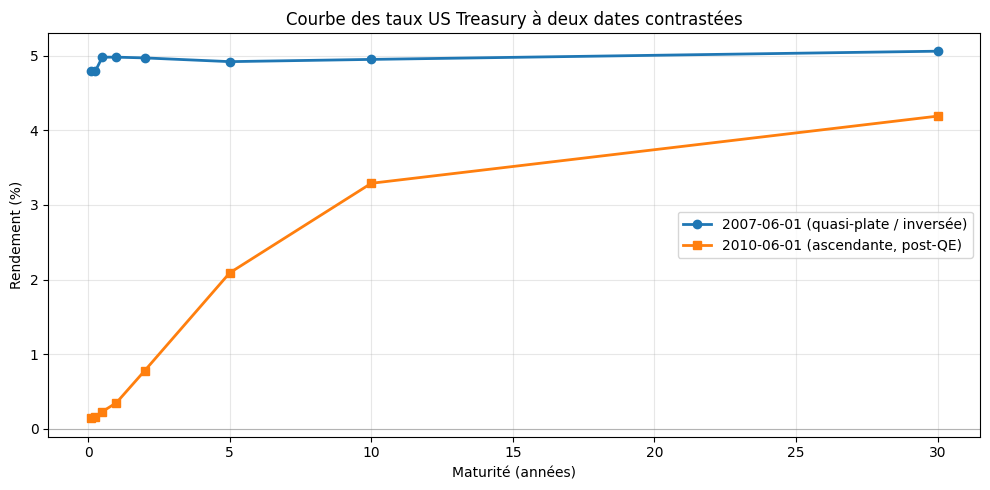

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Options d'affichage pandas utilisées dans tout le notebook.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_PATH = Path("..") / "data" / "raw" / "fred_data.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date")

# Correspondance ticker -> maturité en années
maturities = {
    "DGS1MO": 1 / 12,
    "DGS3MO": 3 / 12,
    "DGS6MO": 6 / 12,
    "DGS1": 1,
    "DGS2": 2,
    "DGS5": 5,
    "DGS10": 10,
    "DGS30": 30,
}
tickers = list(maturities.keys())
x = np.array(list(maturities.values()))

date_pre_crise = "2007-06-01"
date_post_qe = "2010-06-01"

y_pre = df.loc[date_pre_crise, tickers].values
y_post = df.loc[date_post_qe, tickers].values

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y_pre, marker="o", linewidth=2, label=f"{date_pre_crise} (quasi-plate / inversée)")
ax.plot(x, y_post, marker="s", linewidth=2, label=f"{date_post_qe} (ascendante, post-QE)")
ax.axhline(0, color="grey", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Maturité (années)")
ax.set_ylabel("Rendement (%)")
ax.set_title("Courbe des taux US Treasury à deux dates contrastées")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Les deux courbes illustrent deux régimes radicalement différents :

- La courbe du **1ᵉʳ juin 2007** est *presque plate* — les rendements du 3 mois au 30 ans se situent dans une fourchette étroite (environ 0,5 point de pourcentage), avec même une légère inversion sur le segment court. Ce motif reflète une politique monétaire restrictive et des anticipations d'inflation maîtrisée ; il a effectivement précédé la récession de 2008-2009.
- La courbe du **1ᵉʳ juin 2010** est *fortement ascendante* : les taux courts sont quasi nuls (effet de la politique de taux zéro de la Fed), tandis que les taux longs dépassent 4 %. L'écart 30 ans − 3 mois atteint environ 4 points, une pente très forte caractéristique d'une économie en phase de reprise avec des anticipations de remontée future des taux.

C'est précisément cette **variabilité de la forme de la courbe dans le temps** que le projet cherche à modéliser : prédire, à partir des covariables disponibles à la date `t`, la position à l'horizon d'un mois d'un point particulier de la courbe (par défaut, le rendement `DGS10`).

### 1.3 Chargement

Les données ont été téléchargées en amont par le module `src/data.py`, qui interroge l'API FRED, aligne les séries sur un calendrier de jours ouvrés et applique un forward-fill sur les variables macroéconomiques mensuelles. Le résultat est stocké dans `data/raw/fred_data.csv`. On charge ce CSV en indiquant explicitement à pandas que la colonne `date` doit être parsée comme un index temporel.

**Choix de la période 1990-01-01 → aujourd'hui**. Cette fenêtre temporelle répond à trois exigences. (1) *Disponibilité* : la majorité des séries FRED utilisées ici sont publiées sans interruption à partir des années 1990 ; remonter plus loin dans le temps créerait des trous massifs pour certaines maturités. (2) *Couverture de plusieurs régimes économiques* : la période inclut la récession de 2001 (éclatement de la bulle internet), la crise financière de 2008 et sa décennie de taux zéro, le choc COVID de 2020, puis le cycle agressif de hausses de la Fed en 2022-2024 — autant de régimes contrastés nécessaires à un apprentissage généralisable. (3) *Profondeur statistique* : avec environ 9 500 observations quotidiennes, on dispose d'une base suffisante pour réserver plusieurs années au jeu de test sans compromettre l'estimation des modèles sur le train.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # utilisé dans les sections suivantes
import seaborn as sns              # utilisé dans les sections suivantes

# Options d'affichage pandas : on veut voir toutes les colonnes.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Le notebook est dans notebooks/, le CSV dans data/raw/.
DATA_PATH = Path("..") / "data" / "raw" / "fred_data.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date")

Le DataFrame `df` est maintenant chargé en mémoire, indexé par date. Toutes les analyses qui suivent reposent sur ce fichier unique : toute mise à jour des données nécessite de relancer `python src/data.py` pour régénérer le CSV.

### 1.4 Aperçu du dataset

Avant toute analyse statistique, on inspecte la structure brute du DataFrame. On regarde d'abord les premières et dernières lignes (`.head()`, `.tail()`) pour vérifier la plage temporelle et l'intégrité des données, puis `.shape` pour les dimensions totales. À la place de la sortie texte classique de `.info()` — peu lisible dans un rapport — on construit un **tableau récapitulatif** qui fournit pour chaque colonne son type, le nombre de valeurs non-nulles, le nombre de NaN et le pourcentage correspondant, trié par taux de NaN décroissant.

In [3]:
df.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS30,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO,T10Y2Y
date,,,,,,,,,,,,,
1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.5,5.4,8.23,61.729,NaN
1990-01-02,NaN,7.83,7.89,7.81,7.87,7.87,7.94,8.00,127.5,5.4,8.23,61.729,0.07
1990-01-03,NaN,7.89,7.94,7.85,7.94,7.92,7.99,8.04,127.5,5.4,8.23,61.729,0.05
1990-01-04,NaN,7.84,7.90,7.82,7.92,7.91,7.98,8.04,127.5,5.4,8.23,61.729,0.06
1990-01-05,NaN,7.79,7.85,7.79,7.90,7.92,7.99,8.06,127.5,5.4,8.23,61.729,0.09


In [4]:
df.tail()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS30,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO,T10Y2Y
date,,,,,,,,,,,,,
2026-04-14,3.71,3.71,3.73,3.71,3.76,3.87,4.26,4.87,326.588,4.3,3.64,101.5954,0.50
2026-04-15,3.72,3.71,3.72,3.70,3.76,3.90,4.29,4.89,326.588,4.3,3.64,101.5954,0.53
2026-04-16,3.69,3.70,3.71,3.69,3.78,3.91,4.32,4.93,326.588,4.3,3.64,101.5954,0.54
2026-04-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,326.588,4.3,3.64,101.5954,0.55
2026-04-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,326.588,4.3,3.64,101.5954,0.55


In [5]:
df.shape

(9471, 13)

In [6]:
# Récapitulatif par colonne : dtype, non-null, NaN, % NaN (trié décroissant)
nan_recap = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "nan": df.isna().sum(),
    "pct_nan": (df.isna().mean() * 100).round(2),
})
nan_recap.sort_values("pct_nan", ascending=False)

,dtype,non_null,nan,pct_nan
DGS1MO,float64,6179,3292,34.76
DGS3MO,float64,9078,393,4.15
DGS6MO,float64,9078,393,4.15
DGS1,float64,9078,393,4.15
DGS2,float64,9078,393,4.15
DGS5,float64,9078,393,4.15
DGS10,float64,9078,393,4.15
DGS30,float64,9078,393,4.15
T10Y2Y,float64,9470,1,0.01
CPIAUCSL,float64,9471,0,0.00


Le dataset contient **13 variables** observées sur **≈ 9 500 jours ouvrés**, soit environ 36 années de données (1990-01-01 à aujourd'hui). Toutes les colonnes sont de type `float64`, cohérent avec des grandeurs numériques continues ; l'index est un `DatetimeIndex`. La fréquence effective est celle des jours ouvrés (`business days`, du lundi au vendredi), choix cohérent avec les données de marché qui ne sont pas cotées les week-ends. Le tableau récapitulatif fait apparaître une hétérogénéité marquée des valeurs manquantes : la série `DGS1MO` est manquante à environ 35 % parce qu'elle n'a commencé à être publiée par le Trésor US qu'en juillet 2001 ; les autres taux affichent un taux de NaN modéré (environ 4 %) correspondant aux jours fériés américains et à quelques gaps historiques ; les variables macro mensuelles (`CPIAUCSL`, `UNRATE`, `FEDFUNDS`, `INDPRO`) et le spread `T10Y2Y` sont en pratique complets grâce au forward-fill appliqué en amont. Cette structure des valeurs manquantes sera analysée plus en profondeur en Section 2.

### 1.5 Description des variables

Le tableau ci-dessous documente la sémantique de chacune des 13 variables du dataset. On distingue deux grandes catégories :

- les **taux** (`DGSxx`) qui constituent la *courbe des taux* proprement dite, c'est-à-dire les rendements des obligations du Trésor US pour différentes maturités allant de 1 mois à 30 ans ;
- les variables **macroéconomiques** qui décrivent l'état de l'économie américaine (inflation, chômage, taux directeur, production industrielle) et un indicateur **macro dérivé** (le spread 10 ans − 2 ans).

| Ticker FRED | Description | Unité | Fréquence native | Catégorie |
|---|---|---|---|---|
| `DGS1MO` | Rendement du Treasury Bill à 1 mois *(disponible à partir de juillet 2001)* | % annuel | Quotidien | Taux |
| `DGS3MO` | Rendement à 3 mois | % annuel | Quotidien | Taux |
| `DGS6MO` | Rendement à 6 mois | % annuel | Quotidien | Taux |
| `DGS1` | Rendement à 1 an | % annuel | Quotidien | Taux |
| `DGS2` | Rendement à 2 ans | % annuel | Quotidien | Taux |
| `DGS5` | Rendement à 5 ans | % annuel | Quotidien | Taux |
| `DGS10` | Rendement à 10 ans **(variable cible candidate)** | % annuel | Quotidien | Taux |
| `DGS30` | Rendement à 30 ans | % annuel | Quotidien | Taux |
| `CPIAUCSL` | Indice des prix à la consommation (inflation) | Indice base 1982-84 = 100 | Mensuel *(forward-fill)* | Macro |
| `UNRATE` | Taux de chômage US | % | Mensuel *(forward-fill)* | Macro |
| `FEDFUNDS` | Taux effectif des Fed Funds (taux directeur) | % annuel | Mensuel *(forward-fill)* | Macro |
| `INDPRO` | Indice de production industrielle | Indice base 2017 = 100 | Mensuel *(forward-fill)* | Macro |
| `T10Y2Y` | Spread 10 ans − 2 ans (pente de la courbe) | Points de % | Quotidien | Macro dérivé |

Le *forward-fill* appliqué aux variables macro mensuelles signifie que, entre deux publications officielles, la valeur la plus récente disponible est reportée jour par jour : c'est l'information que recevrait en pratique un investisseur à la date `t`. Ce choix évite un biais de *look-ahead* (pas d'usage d'une information future pour remplir le présent) et reste fidèle au flux d'information réel des marchés.

**Usage des variables dans le projet.** Parmi ces 13 séries, `DGS10` sera la **variable cible** à prédire — choix par défaut conforme au sujet, à confirmer en phase 1. Les 12 autres variables serviront de **covariables** pour la régression. Des **features dérivées** — notamment la *pente* (différences entre maturités longues et courtes), la *courbure* (combinaison 2 × 10Y − 2Y − 30Y par exemple) et les *momenta* (variations retardées du rendement 10 ans) — seront construites dans un module de preprocessing ultérieur (`src/preprocessing.py`, non couvert dans ce notebook d'EDA). Ces features enrichissent la représentation sans introduire d'information nouvelle à strictement parler, et devront être évaluées contre la baseline OLS avant d'être conservées dans les modèles finaux.

### 1.6 Statistiques descriptives générales

La méthode `.describe()` fournit un résumé à 8 indicateurs par variable : nombre d'observations non-nulles, moyenne, écart-type, minimum, trois quartiles et maximum. On arrondit à 3 décimales pour améliorer la lisibilité sans perdre d'information significative sur des variables exprimées en pourcentages.

In [ ]:
df.describe().round(3)

Les ordres de grandeur observés sont cohérents avec la littérature macro-financière :

- **Taux Treasury** : les rendements oscillent entre un minimum proche de 0 % (période *zero-lower-bound* post-crise de 2008 et post-COVID) et un maximum d'environ 8 % atteint au début des années 1990. La moyenne des taux longs (DGS10, DGS30) est supérieure à celle des taux courts, ce qui reflète une courbe des taux *en moyenne* ascendante sur la période.
- **Taux de chômage** (`UNRATE`) : plage de 3,5 % à 14,8 %, la valeur maximale correspondant au pic de chômage d'avril 2020 provoqué par la pandémie de COVID-19.
- **Fed Funds** (`FEDFUNDS`) : plage de 0,05 % à ~8 %, avec une moyenne d'environ 2,9 %. Les longues périodes à 0,05 % correspondent à la politique de taux zéro.
- **CPI** (`CPIAUCSL`) : l'indice est monotone croissant (l'inflation cumulée ne peut pas être négative sur le long terme), ce qui explique une très large amplitude entre minimum et maximum ; on reviendra sur la nécessité de différencier cette série en Section 4.
- **Production industrielle** (`INDPRO`) : l'indice oscille autour de sa base 100 (année 2017), avec un minimum à ~60 (début des années 1990) et un maximum à ~104.
- **Spread T10Y2Y** : plage de −1,08 à +2,91 points de %. Les valeurs négatives correspondent aux épisodes d'*inversion de la courbe*, historiquement annonciateurs de récessions.

Ces observations ne sont qu'un premier aperçu : chacune sera détaillée et visualisée dans les sections suivantes, notamment les dynamiques temporelles (Section 2) et les corrélations entre maturités (Section 3).

---

**Prochaine étape** : Section 2 — Statistiques descriptives par famille de variables, visualisations temporelles et analyse des corrélations.

## 2. Statistiques descriptives par famille de variables

### 2.1 Introduction

L'objectif de cette section est de caractériser statistiquement chacune des 13 variables du dataset. Pour rendre cette analyse lisible, nous les regroupons en **trois familles sémantiques**, dont l'unification dans un seul tableau serait trompeuse :

- **Famille A — La courbe des taux Treasury** (8 variables `DGSxx`) : les objets que nous cherchons à modéliser, structurellement très corrélés entre eux ;
- **Famille B — Variables macroéconomiques** (4 variables : `CPIAUCSL`, `UNRATE`, `FEDFUNDS`, `INDPRO`) : indicateurs d'état de l'économie qui servent de covariables ;
- **Famille C — Spread dérivé** (1 variable : `T10Y2Y`) : mesure de pente, interprétée comme indicateur avancé de récession.

Pour chaque famille, nous présenterons (1) une description économique explicite de chaque variable, (2) des statistiques descriptives étendues (moyenne, écart-type, quantiles, skewness, kurtosis), (3) des visualisations temporelles et de distribution, (4) une interprétation reliée aux choix de modélisation à venir.

**Mise en garde méthodologique importante**. Plusieurs des séries étudiées (les huit taux, le CPI et la production industrielle) sont *non stationnaires* en niveau sur la période : leur moyenne et leur variance dépendent du moment où on les observe. Les statistiques descriptives calculées ici doivent donc être lues comme une **description de l'échantillon 1990-2026**, et non comme des paramètres d'une loi sous-jacente stable. Un test formel de stationnarité (ADF) est renvoyé à la Section 3, et conditionnera le choix de travailler sur les niveaux ou sur les différences dans le preprocessing.

On importe `scipy.stats` pour calculer la *skewness* (asymétrie de la distribution) et le *kurtosis* (épaisseur des queues). On définit aussi deux listes de colonnes qui structureront toute la section.

In [ ]:
from scipy import stats

# Listes de colonnes utilisées tout au long de la Section 2
yield_cols = ["DGS1MO", "DGS3MO", "DGS6MO", "DGS1",
              "DGS2", "DGS5", "DGS10", "DGS30"]
macro_cols = ["CPIAUCSL", "UNRATE", "FEDFUNDS", "INDPRO"]


def describe_ext(s: pd.Series) -> pd.Series:
    """Statistiques descriptives étendues pour une série.

    Renvoie count, mean, median, std, min, Q1, Q3, max, skew, kurtosis
    (kurtosis Fisher : 0 pour la loi normale, > 0 si queues plus épaisses).
    Les NaN sont ignorés via nan_policy='omit'.
    """
    return pd.Series({
        "count": s.count(),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "max": s.max(),
        "skew": stats.skew(s, nan_policy="omit"),
        "kurtosis": stats.kurtosis(s, nan_policy="omit"),
    })

### 2.2 Famille A — La courbe des taux Treasury

#### 2.2.1 Description économique des 8 maturités

Les huit maturités ne jouent pas le même rôle économique ; on peut les regrouper en trois blocs avec des logiques distinctes.

- **Taux courts (`DGS1MO`, `DGS3MO`, `DGS6MO`, `DGS1`, `DGS2`)** : ils reflètent principalement la *politique monétaire* de la Réserve Fédérale (taux des *Fed Funds*) et les anticipations de court terme des marchés. Ils réagissent très rapidement aux décisions du FOMC (*Federal Open Market Committee*, qui fixe le taux directeur). Leur volatilité est dominée par les cycles de resserrement/assouplissement monétaires.
- **Taux moyens (`DGS5`)** : zone de transition. Le 5 ans combine un effet politique monétaire (dans la prochaine phase du cycle) et un effet anticipations d'inflation et de croissance à moyen terme.
- **Taux longs (`DGS10`, `DGS30`)** : leur dynamique est dominée par les *anticipations d'inflation de long terme*, la *prime de terme* (prime exigée pour immobiliser de l'argent longtemps) et les flux de demande structurels (assureurs, fonds de pension, investisseurs étrangers). Ce sont eux qui servent de benchmark pour pricer les prêts hypothécaires à taux fixe, les obligations corporate et les swaps de taux.

Ces hétérogénéités expliquent pourquoi les maturités, bien que très corrélées, ne se confondent pas ; les trois facteurs latents niveau / pente / courbure du modèle Nelson-Siegel (1987) suffisent à résumer leur co-mouvement avec une excellente approximation. Regardons maintenant les statistiques empiriques.

#### 2.2.2 Statistiques descriptives

On applique la fonction `describe_ext` à chaque colonne de la famille A. Chaque ligne du tableau ci-dessous correspond à une maturité, chaque colonne à un indicateur statistique.

In [ ]:
stats_yields = df[yield_cols].apply(describe_ext).T.round(3)
stats_yields

Lecture du tableau :

- **Moyennes croissantes avec la maturité** : la moyenne des rendements passe typiquement de l'ordre de 2 % sur le segment très court à environ 4,5 % sur le 30 ans. Cet ordre respecte la forme d'une courbe des taux « normale » en moyenne sur la période — la prime de terme est positive sur un horizon aussi long. `DGS1MO` a une moyenne plus basse parce que sa couverture temporelle commence seulement en 2001 (période en moyenne plus accommodante).
- **Dispersion décroissante avec la maturité** : l'écart-type est plus élevé pour les taux courts (sensibles à chaque décision de la Fed) que pour les taux longs (lissés par les anticipations de long terme). C'est un résultat classique de la littérature sur la structure par terme : les chocs de politique monétaire se transmettent avec une amplitude décroissante vers la partie longue de la courbe.
- **Skewness (asymétrie)** : positive et modérée sur les taux longs (quelques pics à la hausse tirent la queue droite), proche de 1 ou plus sur les taux courts (asymétrie plus marquée, car les taux ont été collés à zéro pendant de longues périodes post-2008 et post-COVID, ce qui crée une queue droite).
- **Kurtosis (Fisher)** : positif et souvent élevé (> 0, parfois > 1). Un kurtosis de Fisher > 0 signifie des queues *plus épaisses que la loi normale* : les événements extrêmes (chocs de taux) sont plus fréquents que ne le prédirait une gaussienne. C'est typique des séries financières.

**Implication pour la modélisation** : les rendements Treasury en niveau ne sont pas gaussiens. Les intervalles de confiance et tests de Student de l'OLS reposent sur une hypothèse de normalité des résidus — hypothèse qu'il faudra vérifier *a posteriori* sur les résidus du modèle, et non *a priori* sur les variables brutes. Ceci sera repris lors de la validation des modèles.

#### 2.2.3 Visualisations temporelles

Le tableau précédent donne une vue statique. On visualise maintenant l'évolution des 8 maturités sur toute la période pour faire apparaître les dynamiques communes et les éventuelles divergences.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(yield_cols)))
for col, color in zip(yield_cols, colors):
    ax.plot(df.index, df[col], label=col, color=color, linewidth=0.8)
ax.set_title("Évolution des rendements Treasury par maturité (1990-aujourd'hui)")
ax.set_xlabel("Date")
ax.set_ylabel("Rendement (%)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Maturité")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Le graphique fait ressortir plusieurs régularités fortes :

- **Tendance baissière globale** des années 1990 jusqu'à 2020 : les rendements passent d'environ 8 % à quasi 0 % sur quarante ans, reflet du régime désinflationniste amorcé après la *Great Inflation* des années 1970-1980 et de l'action combinée de la globalisation et de la démographie vieillissante.
- **Plateau bas 2009-2015** : après la crise financière, les taux courts restent collés à zéro sous l'effet de la *zero interest-rate policy* (ZIRP) de la Fed, et les taux longs sont écrasés par les programmes de *quantitative easing* (achats massifs d'obligations).
- **Remontée brutale 2022-2023** : face à l'inflation post-COVID, la Fed a mené l'un des cycles de hausse les plus rapides de son histoire, ce qui est visible comme un redressement quasi-vertical des taux courts.
- **Co-mouvement très fort** : les huit courbes bougent dans des directions similaires avec des timings quasi-identiques. Cette colinéarité visuelle est l'indice empirique principal qui motivera, au 2.2.5, l'emploi de méthodes régularisées.

#### 2.2.4 Distribution des taux (boxplot et histogrammes)

Au-delà des dynamiques temporelles, on regarde la distribution marginale (sans tenir compte du temps) de chaque taux. Le **boxplot** compare dispersion et médianes entre maturités ; les **histogrammes** donnent la forme fine des distributions — utile pour détecter une éventuelle multimodalité (plusieurs régimes de taux).

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
df[yield_cols].boxplot(ax=ax)
ax.set_title("Distribution des rendements par maturité — boxplot")
ax.set_ylabel("Rendement (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, yield_cols):
    df[col].hist(bins=50, ax=ax, color="steelblue", alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel("Rendement (%)")
    ax.set_ylabel("Fréquence")
    ax.grid(True, alpha=0.3)
plt.suptitle("Histogrammes des rendements Treasury (bins=50)", y=1.02)
plt.tight_layout()
plt.show()

Les distributions ne sont **pas unimodales gaussiennes** : la plupart des histogrammes font apparaître au moins deux bosses — une bosse basse (autour de 0-2 %, période ZIRP et post-COVID) et une bosse plus haute (autour de 4-6 %, régime « normal » des années 1990-2000). Sur `DGS10` notamment, on distingue clairement un mode autour de 2 % et un autre autour de 5 %, avec une zone de relative rareté entre 3 et 4 %. Cette **multimodalité** est le reflet statistique direct de l'existence de régimes monétaires hétérogènes : un modèle qui ignore cette structure (par exemple une régression linéaire sur les niveaux) projette une relation fonctionnelle *en moyenne* sur des régimes très différents, ce qui peut dégrader la performance hors échantillon. C'est un argument supplémentaire pour envisager une modélisation sur les *variations* plutôt que sur les *niveaux* (à trancher après le test ADF).

#### 2.2.5 Corrélations entre maturités

La **corrélation de Pearson** mesure l'intensité du co-mouvement linéaire entre deux séries : elle vaut +1 quand les deux séries montent et descendent ensemble parfaitement, −1 quand elles évoluent en miroir, et 0 quand elles sont linéairement indépendantes. Pour la courbe des taux, on s'attend à des corrélations **très élevées** entre maturités voisines (ex. DGS5 et DGS10), et **plus faibles** entre maturités éloignées (ex. DGS1MO et DGS30), parce que les taux courts et longs obéissent partiellement à des forces différentes (politique monétaire vs anticipations de long terme).

Un niveau de corrélation supérieur à 0,9 entre covariables est un cas manuel de **multicolinéarité**, qui pose trois problèmes à la régression OLS : (1) l'estimation des coefficients devient instable (petite variation des données $\Rightarrow$ grande variation des coefficients), (2) la variance des estimateurs explose (intervalles de confiance très larges), (3) l'interprétation des coefficients individuels perd son sens (on ne peut plus isoler l'effet marginal d'une variable). La **régression régularisée** (Ridge) résout (1) et (2) en pénalisant les coefficients trop grands ; la **régression sur composantes principales** (PCR) et les **moindres carrés partiels** (PLS) résolvent tous les problèmes en travaillant sur un petit nombre de combinaisons linéaires non corrélées des covariables.

In [ ]:
corr_yields = df[yield_cols].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr_yields, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Corrélation (Pearson)"},
)
ax.set_title("Matrice de corrélation — 8 maturités Treasury")
plt.tight_layout()
plt.show()

La heatmap révèle trois faits statistiques saillants :

1. **Toutes les corrélations sont positives et élevées**. Aucune n'est inférieure à 0,5 ; la plupart sont au-dessus de 0,85. Les huit maturités bougent globalement dans le même sens.
2. **Structure de bande** : les corrélations sont plus fortes entre maturités adjacentes (sur la diagonale et ses voisines proches) et s'affaiblissent en s'éloignant de la diagonale. Par exemple, `DGS10 ↔ DGS30` est typiquement autour de 0,97, alors que `DGS1MO ↔ DGS30` tombe vers 0,5-0,7. C'est la signature d'un *processus à facteurs* : quelques composantes communes expliquent l'essentiel du co-mouvement.
3. **Bloc quasi-unitaire sur les taux longs** : les corrélations entre DGS5, DGS10 et DGS30 sont typiquement toutes ≥ 0,95. Ce bloc porte l'essentiel de l'information « niveau » de la courbe.

**Conclusion méthodologique** : cette colinéarité forte est une caractéristique *intrinsèque* du problème (elle est prédite par la théorie Nelson-Siegel), pas un artefact de préparation des données. Elle **justifie empiriquement et sans ambiguïté** l'emploi de Ridge et de PCR dans le projet : une OLS naïve sur ces 8 taux comme covariables produirait des coefficients instables et numériquement problématiques. C'est la principale motivation statistique du choix de méthodes.

### 2.3 Famille B — Variables macroéconomiques

#### 2.3.1 Description économique

Les quatre variables macroéconomiques retenues sont :

- **`CPIAUCSL` — *Consumer Price Index for All Urban Consumers: All Items*** : indice du niveau moyen des prix d'un panier standard de biens et services consommés par les ménages urbains américains. Attention : le CPI *lui-même* est un indice croissant ; c'est son **taux de croissance** (en glissement annuel) qu'on appelle *inflation*. Pourquoi cette variable est pertinente pour prédire les taux : l'**équation de Fisher** relie le taux d'intérêt nominal au taux réel et à l'inflation anticipée ($i_\text{nominal} \approx r_\text{réel} + \pi_\text{anticipée}$) ; l'inflation est donc un déterminant macro de premier ordre des taux longs.
- **`UNRATE` — *Unemployment Rate*** : taux de chômage mensuel publié par le Bureau of Labor Statistics. Pourquoi pertinent : la Fed a un *dual mandate* — stabilité des prix ET plein-emploi. Quand le chômage est élevé, la Fed baisse les taux pour relancer l'activité ; quand il est bas et que l'économie surchauffe, elle les remonte pour contenir l'inflation. Le chômage agit donc indirectement sur les taux courts via la fonction de réaction de la Fed.
- **`FEDFUNDS` — *Effective Federal Funds Rate*** : taux effectif au jour le jour auquel les banques se prêtent entre elles leurs réserves excédentaires. C'est la cible opérationnelle de la politique monétaire américaine : le FOMC fixe un corridor cible, et la Fed intervient sur le marché pour maintenir le taux dans ce corridor. Pourquoi pertinent : `FEDFUNDS` ancre mécaniquement les taux Treasury courts (arbitrage), donc la corrélation attendue avec `DGS1MO`, `DGS3MO`, `DGS6MO` est très élevée.
- **`INDPRO` — *Industrial Production Index*** : indice mensuel du volume de production manufacturière, minière et d'utilités aux États-Unis. Pourquoi pertinent : c'est un *proxy* de la composante réelle du cycle économique. En phase d'expansion (`INDPRO` croissant), les taux longs ont tendance à monter (anticipations de resserrement monétaire et d'inflation) ; en phase de récession (`INDPRO` en baisse), ils tendent à baisser.

#### 2.3.2 Statistiques descriptives

On applique la même fonction `describe_ext` aux 4 variables macro.

In [ ]:
stats_macro = df[macro_cols].apply(describe_ext).T.round(3)
stats_macro

Ces statistiques appellent une **mise en garde forte** : `CPIAUCSL` et `INDPRO` sont des **indices quasi-monotones croissants**. Leur moyenne arithmétique (de l'ordre de 190 pour le CPI, 90 pour INDPRO) et leur écart-type ne décrivent **pas** un processus stable autour d'une tendance centrale ; ils reflètent le fait trivial que l'indice était bas en 1990 et plus haut aujourd'hui. Pour ces deux variables, calculer directement une moyenne ou un écart-type n'a pas d'interprétation économique utile.

Les deux autres variables, `UNRATE` et `FEDFUNDS`, peuvent en revanche être interprétées en niveau : le chômage varie entre 3,5 % et 14,8 % avec une moyenne autour de 5,6 %, le taux des Fed Funds entre 0,05 % et 8 % avec une moyenne autour de 2,9 %. Ces plages sont économiquement significatives.

Pour `CPIAUCSL` et `INDPRO`, on va donc calculer dans la sous-section suivante leur **taux de croissance en glissement annuel (YoY)**, transformation standard qui rend ces séries approximativement stationnaires et économiquement interprétables (inflation et croissance industrielle).

#### 2.3.3 Taux de croissance pour CPI et INDPRO

Le **taux de croissance en glissement annuel** d'une variable $X_t$ est défini comme

$$\text{YoY}_t \;=\; 100 \times \frac{X_t - X_{t-252}}{X_{t-252}}.$$

On utilise un décalage de 252 jours ouvrés parce qu'il correspond approximativement au nombre de jours de cotation dans une année civile (~252 ≈ 365 × 5/7 moins les jours fériés). Appliqué au CPI, cela donne l'**inflation annuelle** publiée habituellement dans les médias ; appliqué à INDPRO, cela donne la **croissance annuelle de la production industrielle**. Les 252 premières valeurs sont nécessairement NaN (pas assez d'historique pour calculer le décalage).

In [ ]:
# Taux de croissance en glissement annuel (252 jours ouvrés ≈ 1 an)
cpi_yoy = 100 * (df["CPIAUCSL"] - df["CPIAUCSL"].shift(252)) / df["CPIAUCSL"].shift(252)
indpro_yoy = 100 * (df["INDPRO"] - df["INDPRO"].shift(252)) / df["INDPRO"].shift(252)

yoy = pd.DataFrame({"CPI_YoY": cpi_yoy, "INDPRO_YoY": indpro_yoy})
yoy.apply(describe_ext).T.round(3)

Les statistiques des séries YoY sont maintenant **économiquement interprétables** :

- **Inflation CPI (YoY)** : moyenne de l'ordre de 2,5 % par an, très proche de la cible implicite de la Fed (2 %). Écart-type modéré de l'ordre de 1,5-2 %. Le minimum est légèrement négatif (déflation ponctuelle pendant la crise financière de 2008-2009), le maximum dépasse 8 % (pic d'inflation post-COVID de 2022).
- **Croissance industrielle (YoY)** : moyenne autour de 1-2 %, compatible avec la croissance potentielle de l'économie américaine. Minimum très négatif (−15 % ou plus pendant les récessions, notamment au pic de la crise financière et au choc COVID) ; maximum positif élevé lors des rebonds post-récession.

Ces moyennes et écart-types décrivent maintenant un **processus plus proche de la stationnarité** : les transformations YoY « gomment » la tendance des indices cumulatifs et renvoient une mesure normalisée du taux de croissance. Ce sont ces séries transformées (plutôt que les niveaux bruts) qui seront utilisées dans le preprocessing final pour la modélisation.

#### 2.3.4 Visualisations temporelles

On regroupe en une grille 2×2 les quatre variables macro — `UNRATE` et `FEDFUNDS` en niveau (déjà interprétables), `CPI_YoY` et `INDPRO_YoY` en taux de croissance annuel — pour visualiser leurs dynamiques respectives sur la période.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(df.index, df["UNRATE"], color="darkred", linewidth=0.8)
axes[0, 0].set_title("Taux de chômage (UNRATE, %)")
axes[0, 0].set_ylabel("%")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df.index, df["FEDFUNDS"], color="navy", linewidth=0.8)
axes[0, 1].set_title("Taux des Fed Funds (FEDFUNDS, %)")
axes[0, 1].set_ylabel("%")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df.index, cpi_yoy, color="darkorange", linewidth=0.8)
axes[1, 0].axhline(2, color="grey", linestyle="--", linewidth=0.8, label="Cible Fed 2%")
axes[1, 0].set_title("Inflation CPI (YoY, %)")
axes[1, 0].set_ylabel("%")
axes[1, 0].legend(loc="upper right")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(df.index, indpro_yoy, color="darkgreen", linewidth=0.8)
axes[1, 1].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axes[1, 1].set_title("Croissance production industrielle (YoY, %)")
axes[1, 1].set_ylabel("%")
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

Les quatre dynamiques racontent l'histoire macro-économique américaine récente :

- **UNRATE** : trois pics correspondent aux trois grandes récessions de la période — 2001 (bulle internet), 2008-2010 (crise financière, pic à ~10 %), 2020 (pandémie COVID, pic à 14,8 % en avril). Entre les pics, le chômage retombe progressivement vers 3,5-4 %, témoin des longues phases d'expansion.
- **FEDFUNDS** : la chronologie de la politique monétaire est lisible comme un livre — resserrements fin 90, cycle de baisses 2001, remontée 2004-2007, effondrement 2008 vers 0 %, longue période ZIRP 2009-2015, normalisation lente 2016-2019, retour à 0 % en 2020, puis cycle de hausses agressif 2022-2023 passant de 0,25 % à ~5,5 % en dix-huit mois — la remontée la plus rapide depuis les années 1980.
- **CPI YoY** : inflation globalement sous 4 % sur 1990-2020, avec un léger passage en déflation en 2009. Pic spectaculaire au-dessus de 8 % en 2022, qui motive précisément le resserrement agressif des Fed Funds de la même période.
- **INDPRO YoY** : croissance industrielle autour de 0-3 % en régime normal, effondrements synchrones des récessions (−15 % en 2009, -15 à -20 % en avril 2020), rebonds rapides post-récession.

Les quatre séries sont visiblement couplées (récessions synchronisées, réponses de politique monétaire aux chocs d'inflation ou d'emploi), ce qu'on quantifiera dans la matrice de corrélation globale de la sous-section 2.5.

### 2.4 Famille C — Spread T10Y2Y

#### 2.4.1 Interprétation économique

Le **spread T10Y2Y** est défini comme la différence entre le rendement du Treasury à 10 ans et celui du Treasury à 2 ans :

$$\text{T10Y2Y}_t \;=\; \text{DGS10}_t - \text{DGS2}_t.$$

En régime économique « normal », ce spread est **positif** : les taux longs sont supérieurs aux taux courts parce que les investisseurs exigent une prime de terme pour immobiliser leur capital plus longtemps. Quand le spread devient **négatif**, on parle d'**inversion de la courbe des taux** : une situation anormale où il est plus coûteux d'emprunter à court terme qu'à long terme. Économiquement, l'inversion révèle que les marchés anticipent une récession future — si l'économie ralentit, la Fed baissera les taux courts à un horizon de 12-24 mois, donc détenir une obligation longue au taux actuel sera rétrospectivement avantageux.

Ce phénomène a une valeur prédictive remarquable : **toutes les récessions américaines depuis 1970 ont été précédées d'une inversion durable du spread T10Y2Y, dans les 6 à 24 mois qui précèdent**. C'est l'un des rares indicateurs avancés à avoir résisté au test du temps, et c'est la raison pour laquelle la Fed de New York publie quotidiennement une probabilité de récession basée sur le spread 10Y−3M. La présence du spread dans notre dataset est donc tout sauf cosmétique : c'est un régresseur à fort pouvoir informationnel sur la dynamique future des taux.

#### 2.4.2 Statistiques et visualisation

On calcule les statistiques descriptives standard et on trace le spread dans le temps, en mettant en évidence visuellement les périodes d'inversion (zones ombrées rouges là où le spread est négatif).

In [ ]:
# Statistiques descriptives du spread
stats_t10y2y = describe_ext(df["T10Y2Y"]).to_frame("T10Y2Y").T.round(3)

# Plot temporel avec ombrage des inversions
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["T10Y2Y"], color="steelblue", linewidth=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.fill_between(
    df.index, df["T10Y2Y"], 0,
    where=(df["T10Y2Y"] < 0), color="red", alpha=0.3,
    label="Inversion (spread < 0)",
)
ax.set_title("Spread T10Y2Y : différence DGS10 − DGS2 (1990-aujourd'hui)")
ax.set_xlabel("Date")
ax.set_ylabel("Spread (points de %)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

stats_t10y2y

Le spread oscille entre environ −1,1 et +2,9 points de pourcentage, avec une moyenne d'environ 1,0 et une médiane proche, ce qui confirme qu'une courbe ascendante est le régime par défaut sur la période. Les zones ombrées rouges révèlent **quatre épisodes majeurs d'inversion** :

- **2000** : inversion précédant la récession de 2001 (éclatement de la bulle internet).
- **2006-2007** : inversion précédant la grande crise financière de 2008-2009, pendant environ 18 mois.
- **Été 2019** : brève inversion, suivie (de manière parfois discutée statistiquement) par la récession COVID de 2020 — même si celle-ci a été déclenchée par un choc exogène, l'inversion préalable indiquait déjà un ralentissement cyclique en cours.
- **2022-2024** : la plus longue inversion de la série (≈ 2 ans), conséquence directe du resserrement ultra-rapide des Fed Funds face à l'inflation post-COVID. Ce signal annonce statistiquement une récession à un horizon 2024-2025.

La **corrélation historique entre inversion et récession ultérieure** est donc visuellement très nette. Pour le projet, cela justifie de conserver `T10Y2Y` comme covariable : bien qu'elle soit une combinaison linéaire de `DGS10` et `DGS2`, elle isole précisément la dimension « pente » qui a une valeur prédictive propre — argument qui sera renforcé par l'analyse en composantes principales de Nelson-Siegel.

### 2.5 Vue d'ensemble cross-familles

#### 2.5.1 Matrice de corrélation globale

Jusqu'ici, on a regardé les trois familles séparément. Pour identifier les **ponts informationnels entre macro et courbe des taux** — qui sont précisément ce que cherche à exploiter le modèle prédictif — on calcule la matrice de corrélation complète sur les 13 variables. Les blocs de forte corrélation inter-familles sont les candidats naturels pour être des régresseurs utiles.

In [ ]:
corr_all = df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_all, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=ax,
    cbar_kws={"label": "Corrélation (Pearson)"},
)
ax.set_title("Matrice de corrélation complète — 13 variables")
plt.tight_layout()
plt.show()

Quatre structures ressortent de la matrice complète :

1. **Bloc intra-taux (8 × 8, coin supérieur gauche)** : déjà analysé en 2.2.5, corrélations très élevées (0,5 à 0,99), structure de bande.
2. **FEDFUNDS ↔ taux courts** : corrélation très forte (typiquement > 0,9 avec `DGS1MO`, `DGS3MO`, `DGS6MO`). C'est la signature directe de la transmission de la politique monétaire : les taux courts Treasury sont mécaniquement ancrés au taux des Fed Funds par arbitrage. Cette redondance signifie que `FEDFUNDS` apporte peu d'information supplémentaire aux taux courts — à garder en tête pour éviter de sur-pondérer cette dimension dans la régression.
3. **CPI en niveau ↔ taux** : corrélation apparemment faible à modérée, résultat contre-intuitif mais **artefact de non-stationnarité**. Le CPI est un indice monotone croissant alors que les taux oscillent ; la corrélation de Pearson entre une série croissante et une série oscillante sous-estime systématiquement la relation économique réelle (qui porte sur la croissance du CPI, pas son niveau). On s'attend à retrouver une corrélation plus claire avec `CPI_YoY` — confirmation à vérifier en Section 3.
4. **T10Y2Y relativement décorrélé des niveaux de taux** : le spread est par construction une *différence* ; il capte l'information de pente, orthogonale à l'information de niveau. C'est précisément ce qui en fait un régresseur complémentaire utile, et non redondant avec `DGS2` ou `DGS10` pris séparément.

Ces observations renforcent trois décisions méthodologiques : (a) **régulariser** (Ridge ou PCR) vu la redondance intra-taux et FEDFUNDS-taux courts, (b) **travailler sur les différences ou taux de croissance** pour CPI et INDPRO afin de révéler leur vraie relation avec les taux, (c) **standardiser** les covariables avant toute régularisation (Ridge pénalise les coefficients en norme $\ell_2$, ce qui n'a pas de sens si les variables ont des échelles hétérogènes — pourcentages, indices à niveaux différents, points de base).

### 2.6 Synthèse de la Section 2

**Sur les distributions.** Les rendements Treasury en niveau ne sont pas gaussiens : skewness légèrement positive, kurtosis de Fisher strictement positif, et surtout multimodalité marquée liée à l'existence de régimes monétaires hétérogènes (pré/post-2008, pré/post-COVID). Les ordres de grandeur sont physiquement cohérents (rendements entre 0 % et 8 %, chômage entre 3,5 % et 14,8 %, inflation typiquement autour de 2-3 % avec pics à 8 % en 2022). Les variables d'indice (CPI, INDPRO) ne sont pas analysables en niveau ; leur transformation en taux de croissance annuel les rend statistiquement exploitables.

**Sur les relations entre variables.** La matrice de corrélation fait apparaître trois blocs structurels : (1) une **très forte colinéarité intra-taux** (souvent > 0,9) résultat direct de la structure factorielle de la courbe, (2) un **couplage mécanique FEDFUNDS–taux courts** reflétant la transmission de la politique monétaire, (3) une **quasi-orthogonalité** du spread T10Y2Y par rapport aux niveaux de taux, confirmant qu'il apporte une information propre (la pente) distincte de l'information niveau.

**Ce qu'il reste à établir.** Les caractères *non stationnaires* des taux en niveau, du CPI et d'INDPRO sont visibles graphiquement mais n'ont pas été **testés formellement**. C'est l'objet de la Section 3 (test de Dickey-Fuller augmenté, ADF), qui tranchera entre modélisation en niveaux, en différences premières ou en taux de croissance. Les résidus des modèles de régression devront aussi être analysés *a posteriori* pour vérifier les hypothèses classiques de l'OLS (normalité, homoscédasticité, non-autocorrélation), ce qui se fera en phase de validation.

**Conséquences pour la modélisation.** Trois choix méthodologiques sont déjà justifiés par l'analyse descriptive seule, sans attendre les tests : (1) **régularisation** (Ridge) ou **réduction de dimension** (PCR, PLS) plutôt qu'OLS naïf sur les 8 taux, en raison de la multicolinéarité ; (2) **standardisation** systématique des covariables dans le pipeline, pour que la pénalité Ridge ait du sens sur des variables à échelles différentes ; (3) probable usage des **différences premières** ou des **taux de croissance YoY** pour les variables non stationnaires en niveau, à confirmer par ADF.

---

**Prochaine étape** : Section 3 — Test formel de stationnarité (Dickey-Fuller augmenté, ADF) et décisions finales de preprocessing pour la modélisation.